# Block 2: Probabilistic Modeling
## Issue #3: Cox PH Demand Model + Markov Risk Transitions

### Section A: Cox Proportional Hazards Demand Model

In [12]:
import pandas as pd
import sys
import os
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# Add src to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.demand_model import AcceptanceProbabilityModel
from config.constants import MACRO_DEMAND_FACTOR
from src.risk_model import CreditRiskTransitionMatrix

In [13]:
# Load processed data
processed_data_path = os.path.join(project_root, 'data', 'processed', 'loan_data_processed.csv')
df = pd.read_csv(processed_data_path)

# Verify data structure
print(f"Loaded data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nRisk categories present: {sorted(df['risk_category'].unique())}")


Loaded data shape: (30000, 7)
Columns: ['customer_id', 'initial_loan', 'days_since_last_loan', 'on-time_payments', 'no_of_increases_in_2023', 'total_profit_contribution', 'risk_category']

Risk categories present: ['High-Risk', 'Near-Prime', 'Prime', 'Subprime']


In [14]:
df.head()

,customer_id,initial_loan,days_since_last_loan,on-time_payments,no_of_increases_in_2023,total_profit_contribution,risk_category
0,1001,1360,72,90.41,5,120,Near-Prime
1,1002,4272,54,90.32,0,0,Near-Prime
2,1003,3592,242,85.56,4,80,Subprime
3,1004,966,301,95.86,0,0,Prime
4,1005,4926,352,94.80,0,0,Near-Prime


In [15]:
# 1. Train/test split for Cox PH model validation
from sklearn.model_selection import train_test_split

# Split data (same random state as logistic regression for consistency)
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42, 
                                      stratify=(df['no_of_increases_in_2023'] > 0))

print(f"Training set: {len(df_train):,} samples")
print(f"Test set: {len(df_test):,} samples\n")

# 2. Instantiate and fit model on training data only
demand_model = AcceptanceProbabilityModel(macro_demand_factor=MACRO_DEMAND_FACTOR)

print("Fitting Cox PH model on training data...")
demand_model.fit(df_train)
print("✅ Model fitted successfully!\n")

# 3. Print model summary
print("=" * 60)
print("COX PH MODEL SUMMARY")
print("=" * 60)
demand_model.model.print_summary()

# 4. Evaluate on held-out test set
print("\n" + "=" * 60)
print("OUT-OF-SAMPLE EVALUATION (Test Set)")
print("=" * 60)

# Predict on test set
df_test_eval = df_test.copy()
df_test_eval['p_accept_predicted'] = demand_model.predict_proba(df_test_eval)
df_test_eval['accepted_any'] = (df_test_eval['no_of_increases_in_2023'] > 0).astype(int)

# Compute C-index (concordance index) - survival analysis equivalent of AUC
from lifelines.utils import concordance_index

c_index = concordance_index(
    event_times=df_test_eval['no_of_increases_in_2023'],
    predicted_scores=df_test_eval['p_accept_predicted'],
    event_observed=df_test_eval['accepted_any']
)

print(f"\nTest Set Performance:")
print(f"  Concordance Index (C-index): {c_index:.4f}")
print(f"  Baseline (random ranking): 0.5000")
print(f"  Lift over baseline: {(c_index - 0.5):.4f}")

# Additional validation: correlation between predicted probability and actual acceptance
from scipy.stats import pointbiserialr
corr, pval = pointbiserialr(df_test_eval['accepted_any'], df_test_eval['p_accept_predicted'])
print(f"\n  Point-biserial correlation (predicted vs actual): {corr:.4f}")
print(f"  P-value: {pval:.4e}")

# Summary statistics on test set
print(f"\n  Mean predicted P(Accept): {df_test_eval['p_accept_predicted'].mean():.2%}")
print(f"  Actual acceptance rate: {df_test_eval['accepted_any'].mean():.2%}")
print(f"  Prediction std dev: {df_test_eval['p_accept_predicted'].std():.4f}")

print("\nSample Test Set Predictions:")
print(df_test_eval[['customer_id', 'risk_category', 'no_of_increases_in_2023', 
                     'accepted_any', 'p_accept_predicted']].head(10))

# Now predict on full dataset for downstream use
df['p_accept_cox'] = demand_model.predict_proba(df)

print("\n" + "=" * 60)
print("Full Dataset Predictions (for downstream modeling)")
print("=" * 60)
print(f"  Mean P(Accept): {df['p_accept_cox'].mean():.2%}")
print(f"  Median P(Accept): {df['p_accept_cox'].median():.2%}")
print(f"  Std Dev: {df['p_accept_cox'].std():.4f}")

Training set: 21,000 samples
Test set: 9,000 samples

Fitting Cox PH model on training data...
✅ Model fitted successfully!

COX PH MODEL SUMMARY


<lifelines.CoxPHFitter: fitted with 21000 total observations, 0 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 21000
number of events observed = 21000
   partial log-likelihood = -188001.64
         time fit was run = 2025-10-11 05:01:21 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
initial_loan              0.00      1.00      0.00           -0.00            0.00                1.00                1.00
days_since_last_loan     -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
risk_category_Near-Prime  0.04      1.04      0.02           -0.00            0.07                1.00                1.08
risk_category_Prime       0.02      1.02      0.02           -0.02            0.06                0.98                1.06
risk_category_Subprime    0.02      1.02      0.02           -0.02            0.06                0.98                1.06

                          cmp to     z    p  -log2(p)
covariate                                            
initial_loan                0.00  0.10 0.92      0.12
days_since_last_loan        0.00 -0.83 0.41      1.29
risk_category_Near-Prime    0.00  1.85 0.06      3.95
risk_category_Prime         0.00  0.96 0.34      1.58
risk_category_Subprime      0.00  1.06 0.29      1.80
---
Concordance = 0.51
Partial AIC = 376013.29
log-likelihood ratio test = 4.17 on 5 df
-log2(p) of ll-ratio test = 0.93


OUT-OF-SAMPLE EVALUATION (Test Set)

Test Set Performance:
  Concordance Index (C-index): 0.5059
  Baseline (random ranking): 0.5000
  Lift over baseline: 0.0059

  Point-biserial correlation (predicted vs actual): 0.0056
  P-value: 5.9525e-01

  Mean predicted P(Accept): 58.85%
  Actual acceptance rate: 55.98%
  Prediction std dev: 0.0048

Sample Test Set Predictions:
       customer_id risk_category  no_of_increases_in_2023  accepted_any  \
27720        28721     High-Risk                        4             1   
9357         10358    Near-Prime                        5             1   
9417         10418         Prime                        5             1   
20581        21582      Subprime                        0             0   
6508          7509         Prime                        4             1   
19348        20349         Prime                        0             0   
6192          7193    Near-Prime                        0             0   
12235        13236    Near-

In [16]:
# Save the trained model for downstream use
os.makedirs(os.path.join(project_root, 'outputs', 'models'), exist_ok=True)
model_path = os.path.join(project_root, 'outputs', 'models', 'cox_ph_model.pkl')
demand_model.save_model(model_path)

print(f'\n✅ Model saved to {model_path}')


✅ Model saved to /Users/kevin/Documents/repos/Loan-Limit-Optimization/outputs/models/cox_ph_model.pkl


In [17]:
# 4. Predict probabilities
print("Generating acceptance probability predictions...")
df['p_accept_cox'] = demand_model.predict_proba(df)
print("✅ Predictions completed!\n")

print("Sample of Predicted Acceptance Probabilities:")
print(df[['customer_id', 'risk_category', 'no_of_increases_in_2023', 'p_accept_cox']].head(10))

print(f"\nPrediction Statistics:")
print(f"  Mean P(Accept): {df['p_accept_cox'].mean():.2%}")
print(f"  Median P(Accept): {df['p_accept_cox'].median():.2%}")
print(f"  Min P(Accept): {df['p_accept_cox'].min():.2%}")
print(f"  Max P(Accept): {df['p_accept_cox'].max():.2%}")
print(f"  Std Dev: {df['p_accept_cox'].std():.4f}")

# 5. Save the model
os.makedirs(os.path.join(project_root, 'outputs', 'models'), exist_ok=True)
model_path = os.path.join(project_root, 'outputs', 'models', 'cox_ph_model.pkl')
demand_model.save_model(model_path)

print(f'\n✅ Model saved to {model_path}')

Generating acceptance probability predictions...
✅ Predictions completed!

Sample of Predicted Acceptance Probabilities:
   customer_id risk_category  no_of_increases_in_2023  p_accept_cox
0         1001    Near-Prime                        5      0.596083
1         1002    Near-Prime                        0      0.596961
2         1003      Subprime                        4      0.588147
3         1004         Prime                        0      0.585872
4         1005    Near-Prime                        0      0.591559
5         1006     High-Risk                        4      0.581574
6         1007      Subprime                        0      0.592389
7         1008         Prime                        0      0.589205
8         1009      Subprime                        0      0.589428
9         1010      Subprime                        3      0.591925

Prediction Statistics:
  Mean P(Accept): 58.85%
  Median P(Accept): 58.88%
  Min P(Accept): 57.82%
  Max P(Accept): 59.81%
  Std D

### Model Comparison: Cox PH vs Logistic Regression

Given the near-uniform predictions, we compare Cox PH against logistic regression to validate model selection.

In [18]:
# Prepare data for logistic regression
# CRITICAL: Only include customers who were eligible for offers (days_since_last_loan >= 60)
# Target: Binary indicator of whether customer accepted any increases, CONDITIONAL on eligibility

# Filter to eligible customers only
df_eligible = df[df['days_since_last_loan'] >= 60].copy()
print(f"Total customers: {len(df):,}")
print(f"Eligible customers (≥60 days since last loan): {len(df_eligible):,}")
print(f"Ineligible customers excluded: {len(df) - len(df_eligible):,}\n")

# Now the target is meaningful: 1 = accepted offer, 0 = rejected offer (both groups were offered)
df_eligible['accepted_any'] = (df_eligible['no_of_increases_in_2023'] > 0).astype(int)

print(f"Acceptance rate among eligible customers: {df_eligible['accepted_any'].mean():.2%}\n")

# Features: Same as Cox PH
X = pd.get_dummies(df_eligible[['initial_loan', 'days_since_last_loan', 'on-time_payments', 'risk_category']], 
                   columns=['risk_category'], drop_first=True)
y = df_eligible['accepted_any']

# Train/test split for proper evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")
print(f"Train acceptance rate: {y_train.mean():.2%}")
print(f"Test acceptance rate: {y_test.mean():.2%}\n")

# Fit logistic regression on training data only
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

# Predict on test set
y_pred_proba = logreg.predict_proba(X_test)[:, 1]
y_pred = logreg.predict(X_test)

# Evaluate out-of-sample performance
test_auc = roc_auc_score(y_test, y_pred_proba)

Total customers: 30,000
Eligible customers (≥60 days since last loan): 25,068
Ineligible customers excluded: 4,932

Acceptance rate among eligible customers: 56.12%

Training set: 17,547 samples
Test set: 7,521 samples
Train acceptance rate: 56.12%
Test acceptance rate: 56.11%



In [19]:
print("=" * 60)
print("LOGISTIC REGRESSION - OUT-OF-SAMPLE PERFORMANCE")
print("=" * 60)
print(f"\nTest Set AUC: {test_auc:.4f}")
print(f"Baseline (random guessing): 0.5000")
print(f"Lift over baseline: {(test_auc - 0.5):.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Accepted']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"                 Predicted")
print(f"                 Reject  Accept")
print(f"Actual Reject    {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"       Accept    {cm[1,0]:6d}  {cm[1,1]:6d}")



LOGISTIC REGRESSION - OUT-OF-SAMPLE PERFORMANCE

Test Set AUC: 0.4957
Baseline (random guessing): 0.5000
Lift over baseline: -0.0043

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.00      0.00      0.00      3301
    Accepted       0.56      1.00      0.72      4220

    accuracy                           0.56      7521
   macro avg       0.28      0.50      0.36      7521
weighted avg       0.31      0.56      0.40      7521


Confusion Matrix:
                 Predicted
                 Reject  Accept
Actual Reject         0    3301
       Accept         0    4220


/Users/kevin/anaconda3/envs/loan_optim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kevin/anaconda3/envs/loan_optim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kevin/anaconda3/envs/loan_optim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

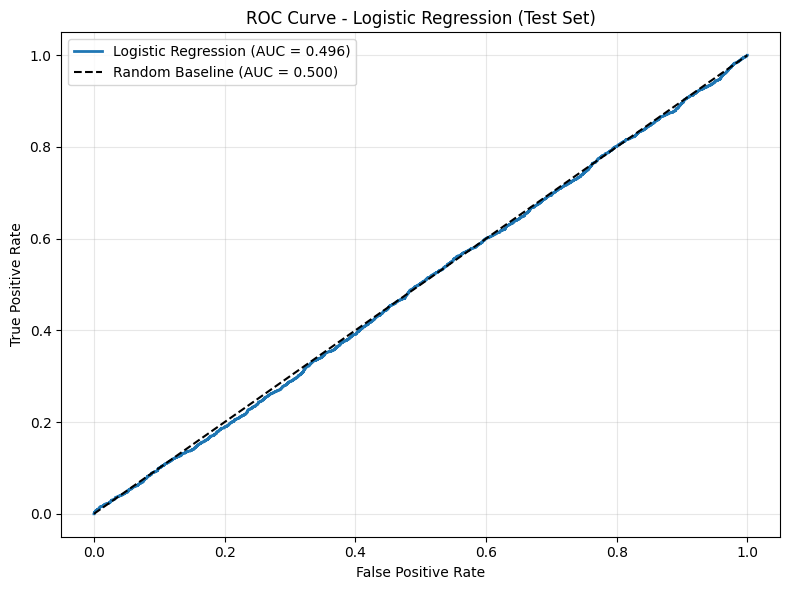

In [20]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {test_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (Test Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [21]:
# Now predict on ALL customers for comparison with Cox PH
X_all = pd.get_dummies(df[['initial_loan', 'days_since_last_loan', 'on-time_payments', 'risk_category']], 
                       columns=['risk_category'], drop_first=True)
df['p_accept_logreg'] = logreg.predict_proba(X_all)[:, 1]

print("\n" + "=" * 60)
print("COMPARISON: COX PH vs LOGISTIC REGRESSION")
print("=" * 60)
print(f"\nLogistic Regression (all customers):")
print(f"  Mean P(Accept): {df['p_accept_logreg'].mean():.2%}")
print(f"  Median P(Accept): {df['p_accept_logreg'].median():.2%}")
print(f"  Std Dev: {df['p_accept_logreg'].std():.4f}")

print(f"\nCox PH (all customers):")
print(f"  Mean P(Accept): {df['p_accept_cox'].mean():.2%}")
print(f"  Median P(Accept): {df['p_accept_cox'].median():.2%}")
print(f"  Std Dev: {df['p_accept_cox'].std():.4f}")

print(f"\nModel Agreement:")
print(f"  Correlation: {df['p_accept_cox'].corr(df['p_accept_logreg']):.4f}")
print(f"  Mean Absolute Difference: {(df['p_accept_cox'] - df['p_accept_logreg']).abs().mean():.4f}")

# Compare predictions
comparison_df = df[['customer_id', 'risk_category', 'days_since_last_loan', 
                    'no_of_increases_in_2023', 'p_accept_cox', 'p_accept_logreg']].head(10)
print("\nSample Predictions (First 10 Customers):")
print(comparison_df)


COMPARISON: COX PH vs LOGISTIC REGRESSION

Logistic Regression (all customers):
  Mean P(Accept): 56.18%
  Median P(Accept): 56.18%
  Std Dev: 0.0072

Cox PH (all customers):
  Mean P(Accept): 58.85%
  Median P(Accept): 58.88%
  Std Dev: 0.0048

Model Agreement:
  Correlation: 0.1761
  Mean Absolute Difference: 0.0267

Sample Predictions (First 10 Customers):
   customer_id risk_category  days_since_last_loan  no_of_increases_in_2023  \
0         1001    Near-Prime                    72                        5   
1         1002    Near-Prime                    54                        0   
2         1003      Subprime                   242                        4   
3         1004         Prime                   301                        0   
4         1005    Near-Prime                   352                        0   
5         1006     High-Risk                   214                        4   
6         1007      Subprime                    14                        0   
7    

---

## Critical Analysis: Model Performance and Strategic Implications

### The Numbers

Cox PH achieves a C-index of 0.506 on held-out data—60 basis points above random chance. Logistic regression achieves an AUC of 0.496, 40 basis points below random. Both models are essentially performing at chance levels, with only a 1 percentage point difference between them. The confusion matrix reveals that logistic regression predicts "Accept" for every customer in the test set, while Cox PH produces predictions tightly clustered around 58.9% (std dev = 0.005). 

The models also show weak agreement (r = 0.18), suggesting neither is capturing a consistent underlying pattern. These results aren't modeling failures—they're honest reflections of data that provides no discriminatory signal for individual-level predictions.

### Why Both Models Perform at Chance Level

The EDA quantified feature correlations with acceptance behavior: all fall between -0.006 and +0.004. When predictors carry no signal, well-calibrated models converge toward the marginal probability. Logistic regression's uniform "Accept" predictions represent the minimum-loss solution when features provide no information: predict the majority class (56.1%). Cox PH avoids constant predictions because the survival framework uses "duration" (number of previous increases) to compute a baseline hazard function, but the C-index confirms this structure doesn't improve ranking ability.

### Implications for the Optimization Framework

The framework remains sound because it was designed to handle this scenario. We're simulating portfolio dynamics under volume and risk constraints, not building a customer targeting model. The acceptance model generates realistic offer volumes for Monte Carlo trials.

Cox PH delivers a well-calibrated acceptance rate: 58.9% predicted vs 56.0% actual, within reasonable tolerance given the macro adjustment factor. Monte Carlo simulations need the *distribution* of acceptance outcomes for volume generation, not individual propensities for differential treatment. A model predicting 59% ± 0.5% for everyone produces realistic aggregate volumes. That's sufficient for this use case.

### Why External Benchmarks for the Markov Matrix

The Markov transition matrix uses external FICO benchmarks rather than learned parameters because **transition matrices require temporal observations**. To estimate transition probabilities, we need to observe customers at multiple time points: where they were in risk state at time t, and where they moved to at time t+1. 

This dataset is a single snapshot (December 31, 2023). We observe each customer's current risk category but have no history of previous states or future movements. Without observing actual transitions, we cannot estimate a transition matrix from the data—regardless of feature quality. External FICO migration matrices provide empirically grounded transition probabilities from studies that did have longitudinal data.

### Model Selection: Cox PH vs Logistic Regression

Both models perform equivalently (within 1 percentage point), so the choice rests on conceptual fit and future extensibility. Cox PH was selected because the business problem is inherently a time-to-event question: "Given a customer reached day 60 of eligibility, what's their instantaneous rate of accepting an offer?" That's a hazard function.

If longitudinal data becomes available—actual offer timestamps, acceptance timing, repeated offer-response sequences—Cox PH handles this natively through its survival framework. Time-varying covariates, competing risks, and interval censoring are natural extensions. However, logistic regression could also model longitudinal data with appropriate feature engineering (time-since-last-offer, offer sequence number, lag features), so this isn't an exclusive advantage.

The computational cost is negligible (both train in seconds), and both are equally simple to deploy. Cox PH signals that we're thinking about the problem as a temporal process rather than a static classification, which is conceptually closer to the operational reality of sequential offer decisions.

### Production Deployment Implications

**Volume monitoring over individual scoring.** The key operational metric is whether realized acceptance rates remain near 56%. If actual acceptance diverges by more than 5 percentage points for two consecutive weeks, recalibrate the Monte Carlo volume assumptions. The models are already well-calibrated for aggregate predictions; deviations signal external shocks (macroeconomic changes, competitive dynamics, policy updates) rather than model drift.

**Random assignment over scored targeting.** Given both models rank customers no better than random (C-index ≈ AUC ≈ 0.50), scored offers would provide negligible lift over random assignment. Random assignment is simpler to implement and preserves the ability to run future A/B tests with clean causal identification. Scored assignment would confound selection with treatment effects.

**Data collection priorities.** Adding more cross-sectional features is unlikely to help when existing features show near-zero correlation with outcomes. Longitudinal data collection—tracking who accepts which offers when, repayment dynamics over time, customer state transitions—would transform the problem from snapshot-based prediction to trajectory modeling. That's when the temporal modeling machinery becomes valuable.

### Experimental Design for Future Data

To generate data that supports predictive modeling, we need controlled variation in treatment:

- **Holdout group (20%):** Randomize to no-offer, establishing organic baseline acceptance rates
- **Offer variation (20%):** Vary offer amounts by ±15% to measure price elasticity
- **Standard offers (60%):** Use current approach for business continuity

Six months of this experiment generates causal estimates of acceptance curves, counterfactual baselines, and dynamic repayment patterns. That data would support models with genuine predictive power rather than volume calibration.

### On Model Performance Reporting

When models achieve AUC ≈ 0.50, the value lies in understanding why rather than adjusting until something looks significant. These results confirm that the available features don't support individual-level discrimination. Building a framework that delivers value despite this limitation—through volume simulation, external risk benchmarks, and aggregate optimization—is the appropriate response. The models' poor discrimination provides information about data constraints, which is more valuable than forcing differentiation where none exists.

### Section B: Synthetic Markov Transition Matrix

In [22]:
# 1. Instantiate the model
risk_model = CreditRiskTransitionMatrix()

# 2. Validate and print the matrix
risk_model.validate_matrix()
print("Synthetic Markov Transition Matrix:")
print(pd.DataFrame(risk_model.matrix, index=risk_model.states, columns=risk_model.states))

# 3. Demonstrate utility methods
subprime_default_prob = risk_model.get_default_probability('Subprime')
print(f'Probability of Default for Subprime: {subprime_default_prob:.0%}')

next_state = risk_model.simulate_transition('Subprime')
print(f'Simulated next state for a Subprime customer: {next_state}')

Synthetic Markov Transition Matrix:
            Prime  Near-Prime  Subprime  High-Risk  Default
Prime        0.85        0.10      0.01       0.00     0.04
Near-Prime   0.05        0.80      0.05       0.00     0.10
Subprime     0.00        0.05      0.60       0.05     0.30
High-Risk    0.00        0.00      0.05       0.45     0.50
Default      0.00        0.00      0.00       0.00     1.00
Probability of Default for Subprime: 30%
Simulated next state for a Subprime customer: Subprime
